Placement Prediction using Machine Learning

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Placement_Data_Full_Class.csv to Placement_Data_Full_Class (2).csv


In [41]:
import pandas as pd
import numpy as np

In [6]:

df = pd.read_csv("Placement_Data_Full_Class (2).csv")

df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


In [9]:
df.columns

Index(['sl_no', 'gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s',
       'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p',
       'status', 'salary'],
      dtype='object')

Data preprocessing was performed by removing unnecessary columns,
handling missing values, and converting the target variable into
binary format.

In [10]:
# Remove useless columns
df = df.drop(["sl_no", "salary"], axis=1)

# Remove missing values
df = df.dropna()

In [11]:
df["status"] = df["status"].map({"Placed": 1, "Not Placed": 0})

## Feature Selection

Selected academic and employability-related features for
model training and evaluation.

In [12]:
X = df[["ssc_p", "hsc_p", "degree_p", "etest_p", "mba_p"]]
y = df["status"]

## Exploratory Data Analysis (EDA)

Exploratory analysis was performed to understand relationships
between academic performance indicators and placement outcomes.

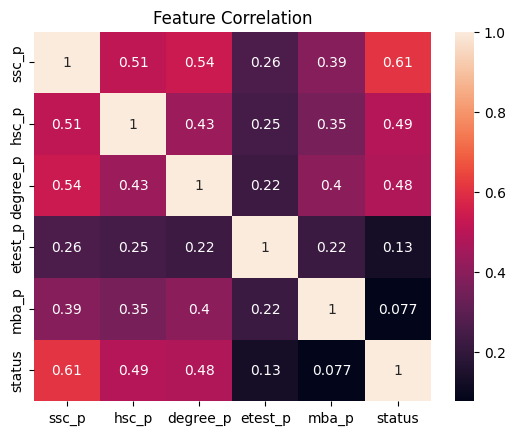

In [22]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

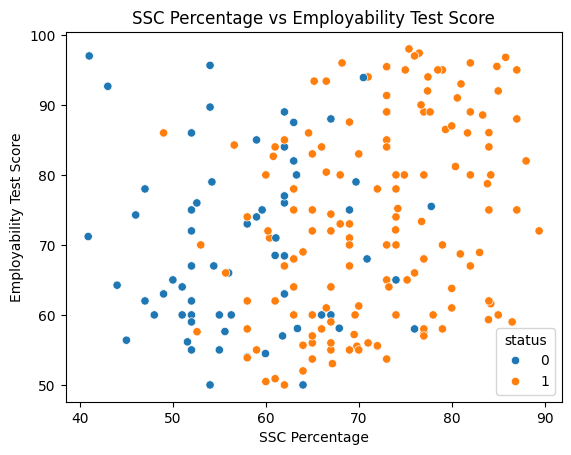

In [44]:
sns.scatterplot(
    x="ssc_p",
    y="etest_p",
    hue="status",
    data=df
)
plt.title("SSC Percentage vs Employability Test Score")
plt.xlabel("SSC Percentage")
plt.ylabel("Employability Test Score")
plt.show()

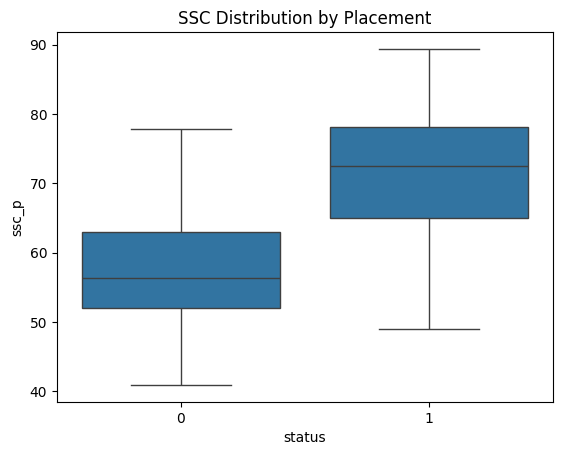

In [20]:
import seaborn as sns

sns.boxplot(x="status", y="ssc_p", data=df)
plt.title("SSC Distribution by Placement")
plt.show()

## Model Training and Evaluation

Three classification models were trained and compared:
- Logistic Regression
- Random Forest
- Decision Tree

Performance was evaluated using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
 f1_score,confusion_matrix,classification_report)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test,y_pred))

Accuracy: 0.7906976744186046
Precision: 0.8055555555555556
Recall: 0.9354838709677419
F1 Score: 0.8656716417910447

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.42      0.53        12
           1       0.81      0.94      0.87        31

    accuracy                           0.79        43
   macro avg       0.76      0.68      0.70        43
weighted avg       0.78      0.79      0.77        43



## Logistic Regression Confusion Matrix

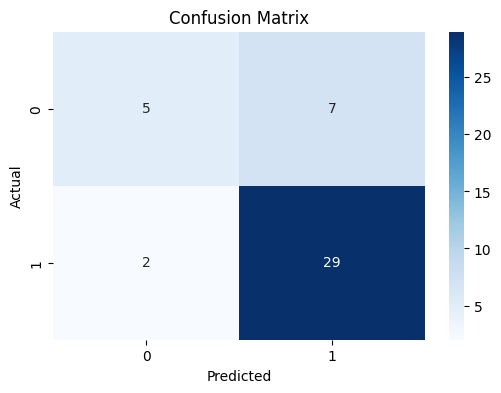

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Random Forest Classifier

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier( n_estimators=100,random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.813953488372093


## Decision Tree Classifier

In [43]:

from sklearn.tree import DecisionTreeClassifier
import pandas as pd
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)



Decision Tree Accuracy: 0.8604651162790697


## Feature Importance Analysis

    Feature  Importance
0     ssc_p    0.479468
4     mba_p    0.273259
1     hsc_p    0.141992
2  degree_p    0.074097
3   etest_p    0.031184


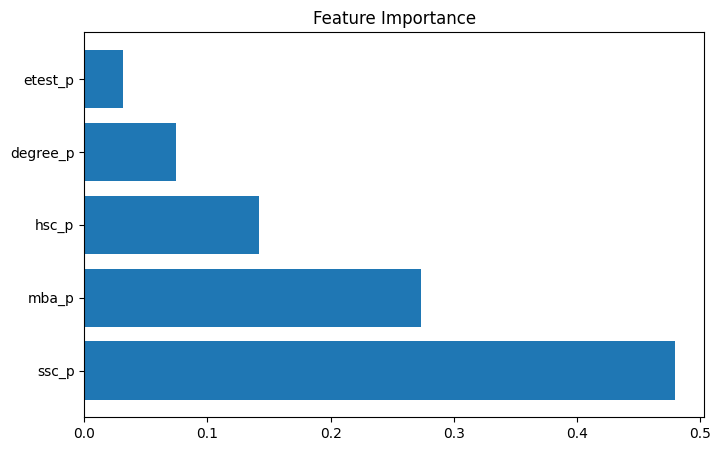

In [42]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)
plt.figure(figsize=(8,5))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.title("Feature Importance")
plt.show()


### Key Findings

- SSC percentage was the most influential predictor.
- MBA percentage was the second most influential feature.
- Employability test score contributed the least to prediction.

## Model Comparison

In [18]:
import pandas as pd

results = pd.DataFrame({
    "Model": [ "Logistic Regression","Random Forest", "Decision Tree"],
    "Accuracy": [accuracy_score(y_test, y_pred), accuracy_score(y_test, rf_pred),
                 accuracy_score(y_test, dt_pred)]
})

results

,Model,Accuracy
0,Logistic Regression,0.790698
1,Random Forest,0.813953
2,Decision Tree,0.860465


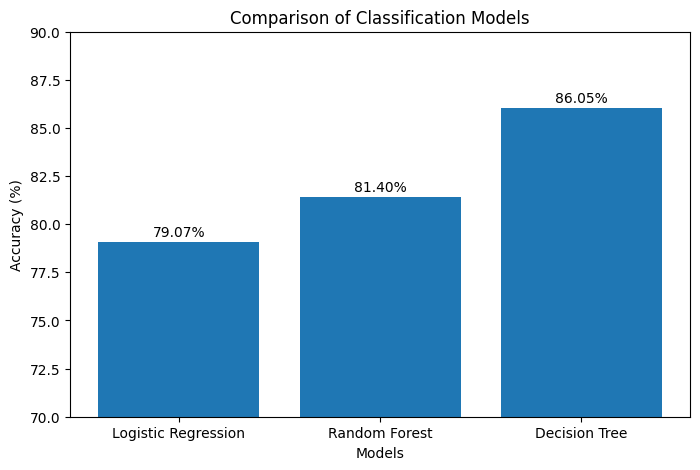

In [40]:
models = ["Logistic Regression", "Random Forest", "Decision Tree"]

accuracies = [accuracy_score(y_test, y_pred)*100,
    accuracy_score(y_test, rf_pred)*100,
    accuracy_score(y_test, dt_pred)*100 ]

plt.figure(figsize=(8,5))

bars=plt.bar(models, accuracies)

plt.ylabel("Accuracy (%)")
plt.xlabel("Models")
plt.title("Comparison of Classification Models")

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.3,
        f"{yval:.2f}%",
        ha='center'
    )

plt.ylim(70,90)

plt.show()

# Feature Engineering Experiment

### Objective
To determine whether adding categorical features improves placement prediction accuracy.

### Added Features
- Gender
- Work Experience
- Specialization
- Degree Type
- HSC Stream

### Method
Categorical variables were encoded using one-hot encoding (`pd.get_dummies()`).

### Results

| Model | Accuracy |
|---------|---------:|
| Decision Tree (Original Features) | 86.05% |
| Decision Tree (Encoded Features) | 83.72% |
| Random Forest (Encoded Features) | 79.07% |

### Conclusion
Adding categorical features did not improve predictive performance on the current dataset. Academic performance indicators remained the strongest predictors of placement outcomes.

In [29]:
df_ml = df.copy()

df_ml = pd.get_dummies(
    df_ml,
    columns=[ "gender", "hsc_s", "degree_t", "workex", "specialisation"],
    drop_first=True
)

print(df_ml.head())

   ssc_p    ssc_b  hsc_p    hsc_b  degree_p  etest_p  mba_p  status  gender_M  \
0  67.00   Others  91.00   Others     58.00     55.0  58.80       1      True   
1  79.33  Central  78.33   Others     77.48     86.5  66.28       1      True   
2  65.00  Central  68.00  Central     64.00     75.0  57.80       1      True   
3  56.00  Central  52.00  Central     52.00     66.0  59.43       0      True   
4  85.80  Central  73.60  Central     73.30     96.8  55.50       1      True   

   hsc_s_Commerce  hsc_s_Science  degree_t_Others  degree_t_Sci&Tech  \
0            True          False            False               True   
1           False           True            False               True   
2           False          False            False              False   
3           False           True            False               True   
4            True          False            False              False   

   workex_Yes  specialisation_Mkt&HR  
0       False                   True  
1 

In [32]:
X_new = df_ml.drop(
    ["status", "ssc_b", "hsc_b"],
    axis=1
)

y_new = df_ml["status"]

print(X_new.head())

   ssc_p  hsc_p  degree_p  etest_p  mba_p  gender_M  hsc_s_Commerce  \
0  67.00  91.00     58.00     55.0  58.80      True            True   
1  79.33  78.33     77.48     86.5  66.28      True           False   
2  65.00  68.00     64.00     75.0  57.80      True           False   
3  56.00  52.00     52.00     66.0  59.43      True           False   
4  85.80  73.60     73.30     96.8  55.50      True            True   

   hsc_s_Science  degree_t_Others  degree_t_Sci&Tech  workex_Yes  \
0          False            False               True       False   
1           True            False               True        True   
2          False            False              False       False   
3           True            False               True       False   
4          False            False              False       False   

   specialisation_Mkt&HR  
0                   True  
1                  False  
2                  False  
3                   True  
4                  False  


In [33]:
from sklearn.model_selection import train_test_split

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new,
    y_new,
    test_size=0.2,
    random_state=42
)

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model_new = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model_new.fit(
    X_train_new,
    y_train_new
)

rf_pred_new = rf_model_new.predict(
    X_test_new
)

rf_acc_new = accuracy_score(
    y_test_new,
    rf_pred_new
)

print("New Random Forest Accuracy:", rf_acc_new)

New Random Forest Accuracy: 0.7906976744186046


In [36]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    dt_model,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())

Cross Validation Scores: [0.8372093  0.81395349 0.81395349 0.76744186 0.69767442]
Mean Accuracy: 0.786046511627907


# Final Conclusion

This project developed a machine learning-based placement prediction system using academic and employability-related features from a student placement dataset.

Data preprocessing was performed by removing irrelevant attributes, handling missing values, and converting the target variable into a machine-readable format. Exploratory Data Analysis (EDA) using heatmaps, boxplots, and scatter plots helped identify relationships between academic performance and placement outcomes.

Three classification algorithms were evaluated:

- Logistic Regression: 79.07% Accuracy
- Random Forest: 81.40% Accuracy
- Decision Tree: 86.05% Accuracy

Among the evaluated models, the Decision Tree Classifier achieved the highest accuracy and was selected as the best-performing model.

Feature importance analysis revealed that SSC percentage was the most influential predictor of placement, followed by MBA percentage and HSC percentage. Employability test scores had comparatively lower influence on prediction outcomes.

A feature engineering experiment was also conducted by incorporating additional categorical variables such as gender, work experience, specialization, degree type, and HSC stream. However, these features did not improve predictive performance, indicating that academic indicators remained the strongest predictors in the current dataset.

Overall, the project demonstrates the complete machine learning workflow including data preprocessing, exploratory analysis, model development, evaluation, feature importance analysis, and feature engineering. The developed system can serve as a foundation for future placement prediction tools and career guidance applications.

## Future Work

- Perform hyperparameter tuning to further optimize model performance.
- Evaluate advanced ensemble methods such as XGBoost and Gradient Boosting.
- Incorporate additional features including internships, technical skills, certifications, and project experience.
- Deploy the model as an interactive Streamlit web application.
- Train and evaluate the model on larger and more diverse placement datasets.